In [1]:
from typing import TypedDict

class State(TypedDict):
    input: str

def function_1(state):
    return {"input": state["input"] + "HI!"}

def function_2(state):
    return {"input": state["input"] + "THERE!"}

In [ ]:
from langgraph.graph import StateGraph
from IPython.display import Image, display

workflow = StateGraph(State)
workflow.add_node("node_1",function_1)
workflow.add_node("node_2",function_2)

workflow.add_edge("node_1","node_2")

workflow.set_entry_point("node_1")
workflow.set_finish_point("node_2")

app=workflow.compile()

display(Image(app.get_graph().draw_mermaid()))

In [ ]:
app.invoke({"input": "HELLO "})

In [ ]:
for output in app.stream({"input": "hello "}):
    for key,value in output.items():
        print(f"Output from node '{key}:'")
        print("--------")
        print(value)

In [3]:
from dotenv import load_dotenv
load_dotenv()

from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite", temperature=0)

d:\Coading\GenAI\ShiaPrasad Valluru Course\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# updated functions with llm calls
def function_1(state):
    response = model.invoke(state["input"])
    return {"input": response.content}

def function_2(state):
    response = model.invoke(state["input"])
    return {"input": response.content}

In [4]:
from langgraph.graph import StateGraph
from IPython.display import Image, display

workflow = StateGraph(State)
workflow.add_node("agent",function_1)
workflow.add_node("node_2",function_2)

workflow.add_edge("agent","node_2")

workflow.set_entry_point("agent")
workflow.set_finish_point("node_2")

app=workflow.compile()

In [ ]:
for output in app.stream({"input": "hello "}):
    for key,value in output.items():
        print(f"Output from node '{key}:'")
        print("--------")
        print(value)

In [ ]:
def function_1(state):
    complete_query = "Your task is not provide a only city name based on the user input. Noting more, just the city name mentioned. Following is the user query: "+state["input"]
    response = model.invoke(complete_query)
    return {"input": response.content}

def function_2(state):
    complete_query = "Provide a brief summary about the city: "+state["input"]
    response = model.invoke(complete_query)
    return {"input": response.content}

In [ ]:
workflow = StateGraph(State)
workflow.add_node("agent",function_1)
workflow.add_node("node_2",function_2)

workflow.add_edge("agent","node_2")

workflow.set_entry_point("agent")
workflow.set_finish_point("node_2")

app=workflow.compile()

In [ ]:
for output in app.stream({"input": "Tell me weather in Pune "}):
    for key,value in output.items():
        print(f"Output from node '{key}:'")
        print("--------")
        print(value)

In [ ]:
AgentState={}
AgentState["messages"]=[] # this is a dictonary of list

AgentState

In [ ]:
def function_1(state):
    state.setdefault("messages", [])
    if not state["messages"]:
        state["messages"].append(state.get("input", ""))
    user_input = state["messages"][-1]
    complete_query = (
        "Your task is to provide only a city name based on the user input. "
        "Nothing more, just the city name mentioned. Following is the user query: "
        + user_input
    )
    response = model.invoke(complete_query)
    state["messages"].append(response.content)
    return state

def function_2(state):
    state.setdefault("messages", [])
    if not state["messages"]:
        state["messages"].append(state.get("input", ""))
    user_input = state["messages"][-1]
    complete_query = "Provide a brief summary about the city: " + user_input
    response = model.invoke(complete_query)
    state["messages"].append(response.content)
    return state

def function_3(state):
    state.setdefault("messages", [])
    if not state["messages"]:
        state["messages"].append(state.get("input", ""))
    user_input = state["messages"][0] if state["messages"] else state.get("input", "")
    available_info = state["messages"][-1]
    complete_query = (
        "Provide travel tips for the city: " + user_input
        + ". Here is some information about the city: " + available_info
    )
    response = model.invoke(complete_query)
    state["messages"].append(response.content)
    state["input"] = response.content  # <- ensure final output is written to 'input'
    return state

In [ ]:
workflow = StateGraph(State)
workflow.add_node("agent",function_1)
workflow.add_node("tool",function_2)
workflow.add_node("responder",function_3)

workflow.add_edge("agent","tool")
workflow.add_edge("tool","responder")

workflow.set_entry_point("agent")
workflow.set_finish_point("responder")

app=workflow.compile()

display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
input_data={"input": "Tell me travel tips for Pune."}

app.invoke(input_data)

In [5]:
# above we are managing the state manually
# to automate this we

from typing import TypedDict, Annotated
import operator
from langgraph.graph import add_messages

class AgentState(TypedDict):
    messages: Annotated[list, operator.add] # annotated list to automatically append lists

In [6]:
def function_1(state):
    state.setdefault("messages", [])
    if not state["messages"]:
        state["messages"].append(state.get("input", ""))
    user_input = state["messages"][-1]
    complete_query = (
        "Your task is to provide only a city name based on the user input. "
        "Nothing more, just the city name mentioned. Following is the user query: "
        + user_input
    )
    response = model.invoke(complete_query)
    # state["messages"].append(response.content) # <- automated by add_messages
    # return state # this is modified to below
    return {"messages": [response.content]}

def function_2(state):
    state.setdefault("messages", [])
    if not state["messages"]:
        state["messages"].append(state.get("input", ""))
    user_input = state["messages"][-1]
    complete_query = "Provide a brief summary about the city: " + user_input
    response = model.invoke(complete_query)
    # state["messages"].append(response.content)
    # return state
    return {"messages": [response.content]}

def function_3(state):
    state.setdefault("messages", [])
    if not state["messages"]:
        state["messages"].append(state.get("input", ""))
    user_input = state["messages"][0] if state["messages"] else state.get("input", "")
    available_info = state["messages"][-1]
    complete_query = (
        "Provide travel tips for the city: " + user_input
        + ". Here is some information about the city: " + available_info
    )
    response = model.invoke(complete_query)
    # state["messages"].append(response.content)
    # state["input"] = response.content  # <- ensure final output is written to 'input'
    # return state
    return {"messages": [response.content], "input": response.content}

In [ ]:
workflow = StateGraph(State)
workflow.add_node("agent",function_1)
workflow.add_node("tool",function_2)
workflow.add_node("responder",function_3)

workflow.add_edge("agent","tool")
workflow.add_edge("tool","responder")

workflow.set_entry_point("agent")
workflow.set_finish_point("responder")

app=workflow.compile()

display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
input_data={"input": "Tell me travel tips for Satara."}

app.invoke(input_data)

In [7]:
from langchain_community.tools.openweathermap import OpenWeatherMapQueryRun

def multiply(a: int, b: int) -> int:
    """Multiply two integers and return the result."""
    return a * b

def add(a: int, b: int) -> int:
    """Add two integers and return the result."""
    return a + b

def divide(a: int, b: int) -> float:
    """Divide first integer by second and return the result."""
    return a / b

In [8]:
tools = [multiply,add,divide]

model = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")
model=model.bind_tools(tools)

In [9]:
def where_to_go(state):
    messages = state['messages']
    last_message = messages[-1]
    print("Inside where to go===",last_message)
    if "tool_calls" in last_message.additional_kwargs:
        return "continue"
    else:
        return "end"

In [10]:
from typing import TypedDict, Annotated
import operator

class AgentState(TypedDict):
    messages: Annotated[list, operator.add]

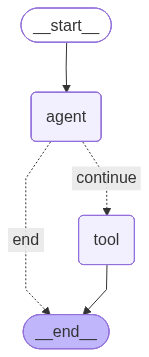

In [ ]:
from langgraph.prebuilt import ToolNode
# tool node takes ai message and calls the tool with proper arguments and return the
# output as tool message

from langgraph.graph import StateGraph, END
from langchain_core.messages import HumanMessage
from langgraph.pregel import retry_policy

def agent(state):
    messages = state['messages']
    response = model.invoke(messages)
    return {"messages": [response]}

workflow = StateGraph(AgentState)

workflow.add_node("agent", agent)
workflow.add_node("tool", ToolNode(tools), retry_policy=3)

workflow.add_conditional_edges("agent",
                               where_to_go, {
                                    "continue": "tool",
                                    "end": END
                                })

workflow.set_entry_point("agent")
app=workflow.compile()

display(Image(app.get_graph().draw_mermaid_png()))

In [12]:
from langchain_core.messages import HumanMessage

input_data = {"messages": [HumanMessage(content="What is 10 multiplied by 5 and then add 20 and divide by 2?")]}
response = app.invoke(input_data)
response

ChatGoogleGenerativeAIError: Invalid argument provided to Gemini: 400 API key not valid. Please pass a valid API key. [reason: "API_KEY_INVALID"
domain: "googleapis.com"
metadata {
  key: "service"
  value: "generativelanguage.googleapis.com"
}
, locale: "en-US"
message: "API key not valid. Please pass a valid API key."
]

In [13]:
import os
print(os.getenv("GOOGLE_API_KEY"))


None
